# AI Text Detection Classifier

**Group Members:** [Pablo Mugica], [Aimar Alustiza], [Mikelats Perez de Iriarte] 

## Overview
This project has a machine learning model to check if a text was written by a human or generated by an AI. It includes data exploration, a PyTorch Lightning neural network, and graphs to evaluate the results.

## Documentation
The auto-generated HTML documentation for the project's source code is published and automatically updated via GitHub Pages. You can explore the modules, classes, and functions here:
 **[View API Documentation](https://aimar-al.github.io/SDOMLpractice/src.html)**

To re-generate the documentation locally using Google docstring style:
```bash
uv run pdoc -d google -o docs src
```


## Data Source
We trained the model using the [benchmark_ai_detection_multimodel_2026.csv](https://www.kaggle.com/datasets/bertnardomariouskono/ai-generated-text-detection-multi-model) dataset. 
This data includes text features like:
* Word count
* Readability score
* Average sentence length
* Simulated perplexity

*Note: Make sure the dataset is inside a `data/` folder in the main project folder.*

## Project Structure
The project uses a clear folder structure to separate data, code, and images:
* `data/`: Has the dataset (or a small sample of it).
* `notebooks/`: Has the main Jupyter Notebook with data exploration, model training, and the evaluation code.
* `reports/figures/`: The folder where all the result images (Confusion Matrix, ROC, Calibration curves) are saved automatically.

## Installation Requirements
This project uses `uv` to manage packages. Because we have a `pyproject.toml` and a `uv.lock` file, you can install all the exact libraries (like PyTorch, Pandas, Scikit-learn, etc.) very easily.

Open your terminal in the project folder and run:

```bash
uv sync
```
## Running with Docker
You can run the Gradio app inside a Docker container, without needing to install Python or any dependencies on your machine. Only Docker is required.

### 1. Pull the image from Docker Hub
```bash
docker pull mikelatsp/ia-generated-text-classifier:latest
```
### 2. Run the container
```bash
docker run --rm -p 7860:7860 mikelatsp/ia-generated-text-classifier:latest
```
### 3. Open the app
Once the container is running, open your browser at:
http://localhost:7860

#  Quickstart & Usage Guide

The following section provides a hands-on example of how to use our pipeline. It demonstrates how to seamlessly load the data, train the neural network, run inference on the datasets, and generate evaluation plots.

If you want to dive deeper into how the code works under the hood, you can explore the technical API documentation for each specific module:

* **Data Handling & Loaders** (`CSVDataModule`, `CSVDataset`): <a href="src/dataset.html" target="_top">Go to src.dataset</a>
* **Model Architecture & Training** (`Net`, `train`): <a href="src/modeling/train.html" target="_top">Go to src.modeling.train</a>
* **Inference & Prediction** (`predict`): <a href="src/modeling/predict.html" target="_top">Go to src.modeling.predict</a>
* **Evaluation Graphics** (`roc_curve`, `confusion_matrix`, etc.): <a href="src/plots.html" target="_top">Go to src.plots</a>


In [2]:
# Import the modules from our project
from src.dataset import CSVDataModule
from src.modeling.train import train
from src.modeling.predict import predict
from src.plots import confusion_matrix, roc_curve, loss_accuracy_curves

## 1. Data Loading
We use `CSVDataModule` to prepare the tensors and DataLoaders required by PyTorch Lightning.

In [3]:
# Initialize the DataModule with the dataset
data_module = CSVDataModule(data_dir="data/benchmark_ai_detection_multimodel_2026.csv", batch_size=64)
data_module.setup()

## 2. Model Training
We use the `train` function, which instantiates our MLP neural network and trains it for 20 epochs, saving the best model automatically.

In [4]:
# Train the model specifying where to save checkpoints and logs
trainer = train(data_module, model_path="models/", logger_path="logs/")

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
/home/alumno/Desktop/datos/SDOMLpractice/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ l1      │ Sequential       │    834 │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 834                                                                                              
Non-trainable params: 0                                                                                            
Total params: 834                                                                                                  
Total estimated model params size (MB): 0.003                                                                      
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/alumno/Desktop/datos/SDOMLpractice/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/alumno/Desktop/datos/SDOMLpractice/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/home/alumno/Desktop/datos/SDOMLpractice/.venv/lib/python3.11/site-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=20` reached.


## 3. Prediction and Inference
We load the best saved checkpoint to make predictions on our data.

In [5]:
# Make predictions (returns predicted labels and probabilities)
y_pred, y_prob = predict(trainer, data_module, path="models/last.ckpt") # Replace with your best checkpoint

# Get the ground truth labels from the dataset
y_true = data_module.train_ds.y

Output()

/home/alumno/Desktop/datos/SDOMLpractice/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/alumno/Desktop/datos/SDOMLpractice/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


## 4. Evaluation and Plotting
Finally, we use the plots module to generate performance visualizations.

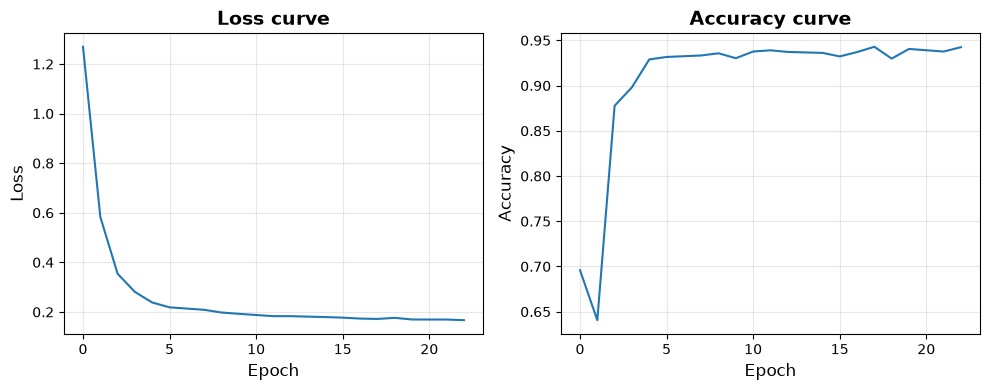

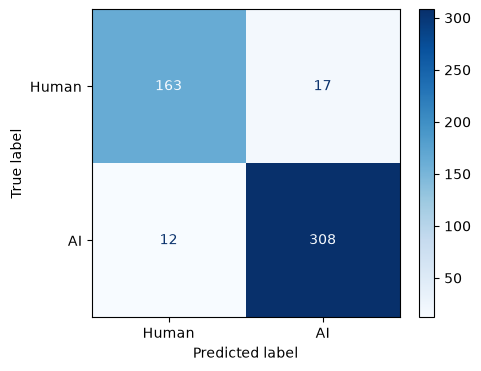

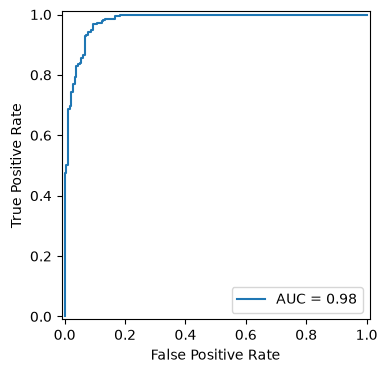

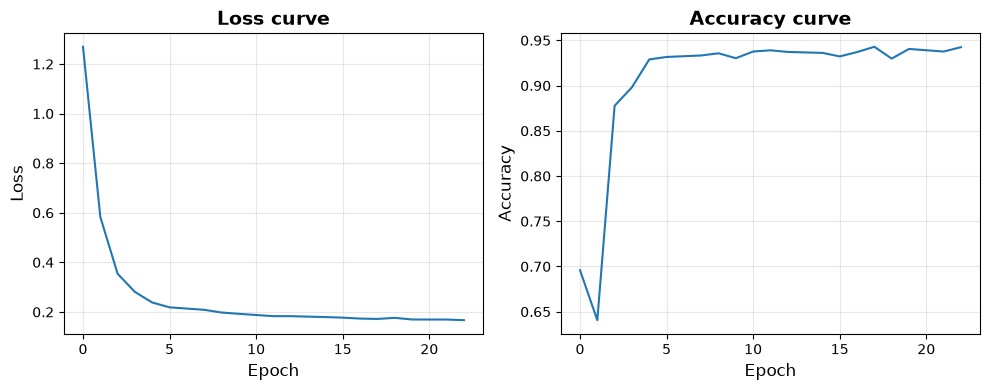

In [6]:
# Confusion Matrix
confusion_matrix(y_true, y_pred, path="reports/figures/cm_tutorial.png")

# ROC Curve
roc_curve(y_true, y_prob, path="reports/figures/roc_tutorial.png")

# Training loss and accuracy curves
loss_accuracy_curves(image_path="reports/figures/curves_tutorial.png", log_path="logs/train_log/version_0/metrics.csv")